In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qfso.wht_sampler.fourier_decomposition import WalshHadamardDecomposition
from qfso.wht_sampler.utils import discretized_normal_probability, WH_fixed_order_ids, exact_WH_coefficient

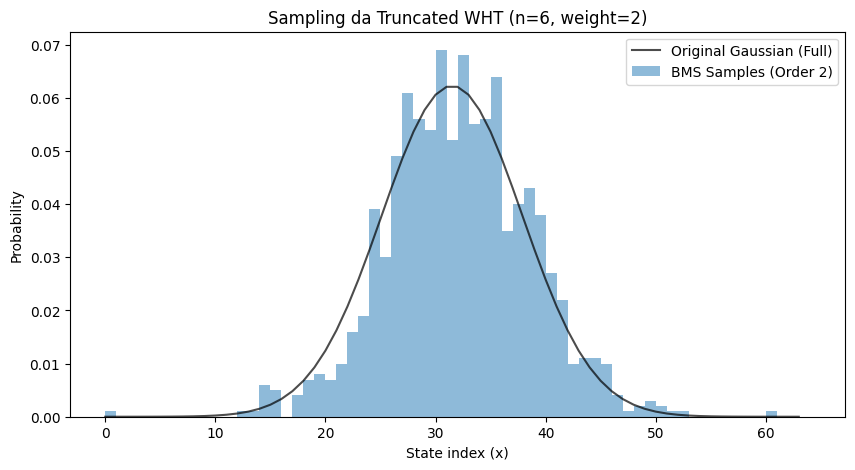

In [3]:
n_qubits = 6
truncation_order = [0,1,2]  # Includiamo identità, single-bit e two-bit parities
interval = (-5, 5)
n_bins = 2**n_qubits

# Generazione della distribuzione target (Gaussian)
# Questa rappresenta la distribuzione ideale che vogliamo approssimare
p_target = discretized_normal_probability(interval, n_bins, loc=0)

# Estrazione dei coefficienti WH
# Generiamo gli identificatori per le stringhe di Pauli fino al peso 2
ids = WH_fixed_order_ids(n_qubits, truncation_order)

# Calcoliamo i coefficienti esatti m_S = E[chi_S] per la nostra Gaussiana
# In un setup reale, questi verrebbero stimati dai dati o da un circuito IQP
target_coeffs = [exact_WH_coefficient(p_target, i) for i in ids]

# Inizializzazione del Decomposer con la distribuzione troncata
wh_decomp = WalshHadamardDecomposition(identifiers=ids, n=n_qubits)
wh_decomp.coefficients = target_coeffs

# Sampling tramite algoritmo BMS
n_samples = 1000
bms_samples = [wh_decomp.sample() for _ in range(n_samples)]

# Analisi dei risultati: Confronto delle distribuzioni
plt.figure(figsize=(10, 5))
plt.plot(p_target, label="Original Gaussian (Full)", color='black', alpha=0.7)

# Istogramma dei campioni generati dal BMS
plt.hist(bms_samples, bins=n_bins, density=True, range=(0, n_bins), 
         alpha=0.5, label=f"BMS Samples (Order {truncation_order[-1]})", color='tab:blue')

plt.title(f"Sampling da Truncated WHT (n={n_qubits}, weight={truncation_order[-1]})")
plt.xlabel("State index (x)")
plt.ylabel("Probability")
plt.legend()
plt.show()